# NFHS-5 Stunting — clean pipeline
Simplified from the original 106-cell notebook. Produces the **exact same**
`final_table`, `map_data`, `state_stunting`, and `stunting_map` objects —
just without the exploration/debugging cells.

In [5]:
import pandas as pd
import numpy as np
import geopandas as gpd

KR_PATH    = r"C:\Users\91981\Downloads\IAKR7EDT\IAKR7EFL.DTA"
INDIA_JSON = r"C:\Users\91981\Desktop\Stunting folder\india.json"

## 1. Load & clean stunting

In [6]:
df = pd.read_stata(KR_PATH, convert_categoricals=False)

# height-for-age z-score: blank out special missing codes (>=9996)
df["hw70_clean"] = df["hw70"].where(df["hw70"] < 9996, np.nan)

# plausibility guard: WHO flags z-scores beyond +/-6 SD as implausible
# (data/measurement errors, not real children). Stored x100, so +/-600.
n_before = df["hw70_clean"].notna().sum()
df["hw70_clean"] = df["hw70_clean"].where(df["hw70_clean"].between(-600, 600), np.nan)
n_dropped = n_before - df["hw70_clean"].notna().sum()
print(f"plausibility guard dropped {n_dropped:,} implausible z-scores "
      f"({100*n_dropped/n_before:.2f}% of measured)")

# stunted = HAZ below -2 SD (stored x100, so < -200); survey weight
df["stunted"] = (df["hw70_clean"] < -200).astype(int)
df["weight"]  = df["v005"] / 1_000_000

# children with a valid measurement (under-5s with plausible anthropometry)
valid = df[df["hw70_clean"].notna()].copy()

national = np.average(valid["stunted"], weights=valid["weight"])
print(f"Rows: {df.shape[0]:,} | valid: {len(valid):,} | national stunting: {100*national:.1f}%")

C:\Users\91981\AppData\Local\Temp\ipykernel_39508\3939757545.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["hw70_clean"] = df["hw70"].where(df["hw70"] < 9996, np.nan)
C:\Users\91981\AppData\Local\Temp\ipykernel_39508\3939757545.py:15: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["stunted"] = (df["hw70_clean"] < -200).astype(int)
C:\Users\91981\AppData\Local\Temp\ipykernel_39508\3939757545.py:16: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, whic

plausibility guard dropped 0 implausible z-scores (0.00% of measured)
Rows: 232,920 | valid: 206,025 | national stunting: 35.5%


## 2. State code → name

In [7]:
state_map = {
 1:'jammu & kashmir',2:'himachal pradesh',3:'punjab',4:'chandigarh',5:'uttarakhand',
 6:'haryana',7:'nct of delhi',8:'rajasthan',9:'uttar pradesh',10:'bihar',11:'sikkim',
 12:'arunachal pradesh',13:'nagaland',14:'manipur',15:'mizoram',16:'tripura',
 17:'meghalaya',18:'assam',19:'west bengal',20:'jharkhand',21:'odisha',22:'chhattisgarh',
 23:'madhya pradesh',24:'gujarat',25:'dadra & nagar haveli and daman & diu',
 27:'maharashtra',28:'andhra pradesh',29:'karnataka',30:'goa',31:'lakshadweep',
 32:'kerala',33:'tamil nadu',34:'puducherry',35:'andaman & nicobar islands',
 36:'telangana',37:'ladakh'
}

## 3. Weighted per-state rates
One helper does the weighted mean; one loop builds every state's poor rate,
rich rate, gap, and overall stunting in a single pass.

In [8]:
def wmean(d):
    return np.average(d["stunted"], weights=d["weight"]) if len(d) else np.nan

rows = []
for code_ in sorted(valid["v024"].unique()):
    s    = valid[valid["v024"] == code_]
    poor = s[s["v190"] == 1]
    rich = s[s["v190"] == 5]
    if len(poor) == 0 or len(rich) == 0:
        continue
    pr, rr = wmean(poor), wmean(rich)
    rows.append({
        "state_code": code_,
        "poor_rate":  pr,
        "rich_rate":  rr,
        "gap":        pr - rr,
        "stunting_rate": wmean(s),
    })

state_gap = pd.DataFrame(rows)
state_gap["state"]        = state_gap["state_code"].map(state_map)
state_gap["gap_pp"]       = (state_gap["gap"] * 100).round(1)
state_gap["poor_pct"]     = (state_gap["poor_rate"] * 100).round(1)
state_gap["rich_pct"]     = (state_gap["rich_rate"] * 100).round(1)
state_gap["stunting_pct"] = (state_gap["stunting_rate"] * 100).round(1)

# wealth-gap table (same columns/order as the original final_table)
final_table = (state_gap[["state","poor_rate","rich_rate","gap_pp","poor_pct","rich_pct"]]
               .sort_values("gap_pp", ascending=False)
               .reset_index(drop=True))

# overall-stunting table (same as the original state_stunting)
state_stunting = state_gap[["v024" if False else "state_code","stunting_rate","stunting_pct","state"]].copy()
state_stunting = state_stunting.rename(columns={"state_code":"v024"})

final_table.head(10)

,state,poor_rate,rich_rate,gap_pp,poor_pct,rich_pct
0,nct of delhi,0.733802,0.251201,48.3,73.4,25.1
1,meghalaya,0.514654,0.073898,44.1,51.5,7.4
2,haryana,0.560923,0.196114,36.5,56.1,19.6
3,goa,0.552777,0.227390,32.5,55.3,22.7
4,odisha,0.432007,0.111035,32.1,43.2,11.1
5,jharkhand,0.465598,0.173791,29.2,46.6,17.4
6,bihar,0.493919,0.202447,29.1,49.4,20.2
7,punjab,0.478002,0.196496,28.2,47.8,19.6
8,andhra pradesh,0.481482,0.205115,27.6,48.1,20.5
9,tamil nadu,0.450602,0.178783,27.2,45.1,17.9


## 4. Save the gap table

In [9]:
final_table.to_csv("state_stunting_gap.csv", index=False)
print("saved state_stunting_gap.csv")

saved state_stunting_gap.csv


## 5. Merge onto geometry
Loads india.json, normalises names, applies the name crosswalk, and merges.
Produces both `map_data` (wealth gap) and `stunting_map` (overall stunting).

In [10]:
states = gpd.read_file(INDIA_JSON)
states["name_clean"] = states["name"].str.lower().str.strip()
# fix the one accented name so it matches
states["name_clean"] = states["name_clean"].replace({
    "dādra and nagar haveli and damān and diu": "dadra & nagar haveli and daman & diu"
})

# crosswalk: NFHS naming -> geojson naming
NAME_FIX = {
    "andaman & nicobar islands": "andaman and nicobar",
    "nct of delhi":              "delhi",
    "jammu & kashmir":           "jammu and kashmir",
    "odisha":                    "orissa",
    "uttarakhand":               "uttaranchal",
}
def to_geo_name(s):
    return s.str.lower().str.strip().replace(NAME_FIX)

final_table["state_clean"]    = to_geo_name(final_table["state"])
state_stunting["state_clean"] = to_geo_name(state_stunting["state"])

map_data     = states.merge(final_table,    left_on="name_clean", right_on="state_clean", how="left")
stunting_map = states.merge(state_stunting, left_on="name_clean", right_on="state_clean", how="left")

print("gap unmatched:",      map_data["gap_pp"].isna().sum())
print("stunting unmatched:", stunting_map["stunting_pct"].isna().sum())

gap unmatched: 1
stunting unmatched: 1


## 6. Maps

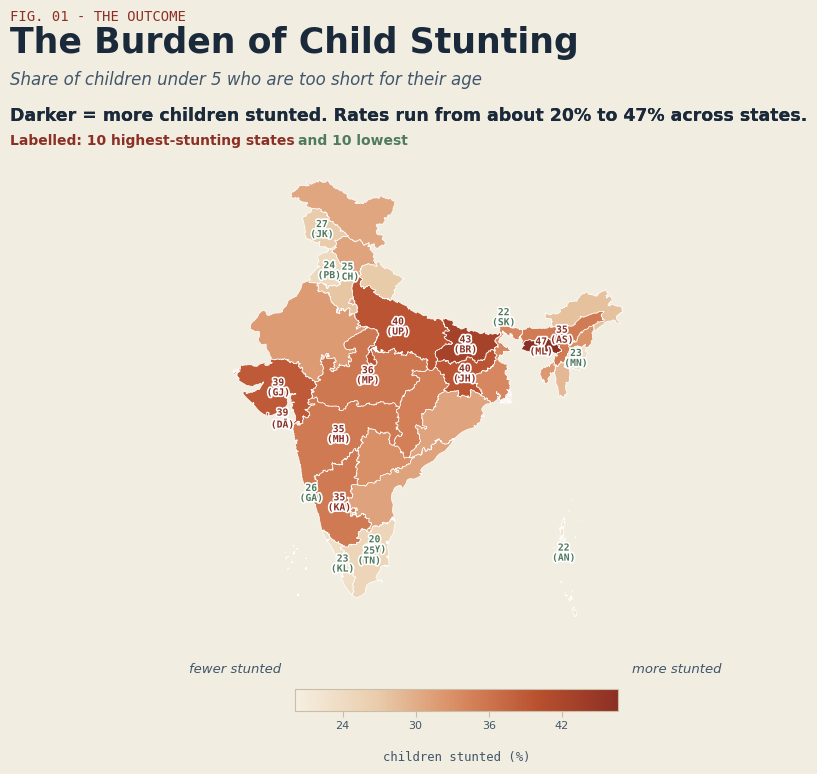

In [19]:
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.ticker import MaxNLocator
from matplotlib import patheffects as pe
import matplotlib as mpl
import numpy as np

gdf = stunting_map

# ---- Lahchen Maps palette ----
PAPER="#f2ede1"; INK="#1b2a3a"; INKSOFT="#41566b"; RULE="#c9bfa8"
OXBLOOD="#8c2f24"; GREEN="#4f7a5e"
ramp = LinearSegmentedColormap.from_list("lahchen",
        ["#f6efe1","#e9cdac","#d98c63","#b9512f","#8c2f24"])
HALO = [pe.withStroke(linewidth=2.4, foreground="white")]

STATE_ABBR = {  # states + UTs
 "andhra pradesh":"AP","arunachal pradesh":"AR","assam":"AS","bihar":"BR","chhattisgarh":"CG",
 "goa":"GA","gujarat":"GJ","haryana":"HR","himachal pradesh":"HP","jharkhand":"JH",
 "karnataka":"KA","kerala":"KL","madhya pradesh":"MP","maharashtra":"MH","manipur":"MN",
 "meghalaya":"ML","mizoram":"MZ","nagaland":"NL","odisha":"OD","orissa":"OD","punjab":"PB",
 "rajasthan":"RJ","sikkim":"SK","tamil nadu":"TN","telangana":"TG","tripura":"TR",
 "uttar pradesh":"UP","uttarakhand":"UK","uttaranchal":"UK","west bengal":"WB","delhi":"DL",
 "nct of delhi":"DL","jammu and kashmir":"JK","jammu & kashmir":"JK","puducherry":"PY",
 "chandigarh":"CH","andaman and nicobar":"AN","ladakh":"LA","lakshadweep":"LD"}
def _abbr(n): return STATE_ABBR.get(str(n).strip().lower(), str(n)[:2].upper())

col = "stunting_pct"
d = gdf.dropna(subset=[col]).copy()
vmin, vmax = d[col].min(), d[col].max()

fig = plt.figure(figsize=(9.5, 12)); fig.patch.set_facecolor(PAPER)
ax = fig.add_axes([0.04, 0.46, 0.92, 0.40]); ax.set_facecolor(PAPER); ax.axis("off")

gdf.plot(column=col, cmap=ramp, vmin=vmin, vmax=vmax, linewidth=0.5,
         edgecolor="white", ax=ax,
         missing_kwds={"color":"#dcd4c2","edgecolor":"white","linewidth":0.5})
hi = d[col].max()
lo = d[col].min()
fig.text(
    0.06, 0.892,
    f"Darker = more children stunted. Rates run from about "
    f"{lo:.0f}% to {hi:.0f}% across states.",
    fontsize=12.5,
    color=INK,
    fontweight="bold"
)


# legend for the label colours
fig.text(0.06, 0.872,
         "Labelled: 10 highest-stunting states", fontsize=10,
         color=OXBLOOD, fontweight="bold")
fig.text(0.363, 0.872,
         "and 10 lowest", fontsize=10,
         color=GREEN, fontweight="bold")

# label only top 10 + bottom 10 (value + shorthand) to avoid overlap
# label only top 10 + bottom 10 (value + shorthand), coloured by group
dd = d.sort_values(col, ascending=False)
top10 = set(dd.head(10)["name"])   # highest stunting
bot10 = set(dd.tail(10)["name"])   # lowest stunting
keep = top10 | bot10
for _, r in gdf.iterrows():
    if r["name"] not in keep or r.geometry is None:
        continue
    c = r.geometry.centroid
    label_color = OXBLOOD if r["name"] in top10 else GREEN
    ax.annotate(f"{r[col]:.0f}\n({_abbr(r['name'])})", (c.x, c.y),
                ha="center", va="center", fontsize=7, color=label_color,
                family="monospace", linespacing=1.0, fontweight="bold",
                path_effects=HALO)

# titles
fig.text(0.06, 0.975, "FIG. 01 - THE OUTCOME", family="monospace", fontsize=10, color=OXBLOOD)
fig.text(0.06, 0.948, "The Burden of Child Stunting", fontsize=25, fontweight="bold", color=INK)
fig.text(0.06, 0.922, "Share of children under 5 who are too short for their age",
         fontsize=12, color=INKSOFT, style="italic")
hi = d.nlargest(1, col).iloc[0]; lo = d.nsmallest(1, col).iloc[0]
fig.text(0.06, 0.892, f"Darker = more children stunted. Rates run from about "
         f"{lo[col]:.0f}% to {hi[col]:.0f}% across states.",
         fontsize=12.5, color=INK, fontweight="bold")


# descriptive legend
cax = fig.add_axes([0.36, 0.40, 0.34, 0.018])
cb = mpl.colorbar.ColorbarBase(cax, cmap=ramp, norm=Normalize(vmin, vmax),
                               orientation="horizontal")
cb.outline.set_edgecolor(RULE)
ticks = MaxNLocator(nbins=5, prune="both").tick_values(vmin, vmax)
cb.set_ticks([t for t in ticks if vmin<=t<=vmax])
cb.ax.tick_params(labelsize=8, color=RULE, labelcolor=INKSOFT, length=4, pad=3)
fig.text(0.345, 0.432, "fewer stunted", fontsize=9.5, color=INKSOFT, ha="right", style="italic")
fig.text(0.715, 0.432, "more stunted",  fontsize=9.5, color=INKSOFT, ha="left",  style="italic")
fig.text(0.53, 0.358, "children stunted (%)", fontsize=8.8, color=INKSOFT, ha="center", family="monospace")


plt.savefig("fig1_stunting_map.png", dpi=400, bbox_inches="tight", facecolor=PAPER)
plt.show()


income merged. missing income for: ['Dādra and Nagar Haveli and Damān and Diu', 'Lakshadweep', 'Ladakh']


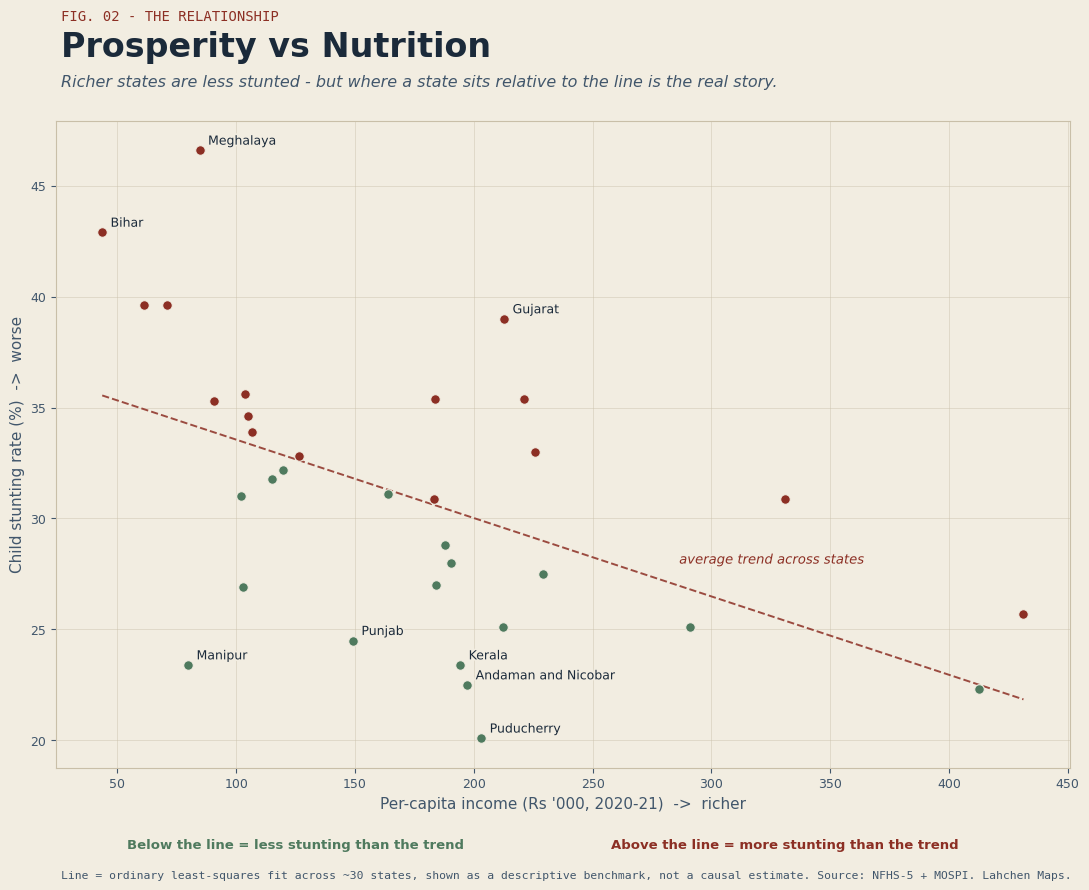

In [12]:
import matplotlib.pyplot as plt
from matplotlib import patheffects as pe
import numpy as np
import pandas as pd

# per-capita income (Rs, 2020-21) — same data as the cartogram
income = pd.DataFrame({
    "region": ["andhra pradesh","arunachal pradesh","assam","bihar","chhattisgarh",
        "goa","gujarat","haryana","himachal pradesh","jharkhand","karnataka","kerala",
        "madhya pradesh","maharashtra","manipur","meghalaya","mizoram","nagaland","odisha",
        "punjab","rajasthan","sikkim","tamil nadu","telangana","tripura","uttar pradesh",
        "uttarakhand","west bengal","andaman & nicobar islands","chandigarh","delhi",
        "jammu & kashmir","puducherry"],
    "income_pc": [163746,190212,90482,43605,104788,431351,212821,229065,183333,71071,
        221310,194322,103654,183704,79797,84638,187838,126452,102166,149193,115122,
        412754,212174,225687,119789,61374,184002,106510,197275,291194,331112,102803,203178]
})

# align income names to the geojson naming (same crosswalk you used for stunting)
income["state_clean"] = income["region"].replace({
    "andaman & nicobar islands":"andaman and nicobar",
    "jammu & kashmir":"jammu and kashmir",
    "odisha":"orissa",
    "uttarakhand":"uttaranchal",
    "delhi":"delhi",
})

# merge onto the geo frame by the same cleaned name key
stunting_map = stunting_map.merge(
    income[["state_clean","income_pc"]],
    left_on="name_clean", right_on="state_clean", how="left"
)

print("income merged. missing income for:",
      stunting_map.loc[stunting_map["income_pc"].isna(), "name"].tolist())
gdf = stunting_map   # must contain income_pc and stunting_pct columns

# ---- Lahchen Maps palette ----
PAPER="#f2ede1"; INK="#1b2a3a"; INKSOFT="#41566b"; RULE="#c9bfa8"
OXBLOOD="#8c2f24"; GREEN="#4f7a5e"; PLOT="#2d4a63"
HALO = [pe.withStroke(linewidth=2.5, foreground=PAPER)]

# ---- data ----
d = gdf.dropna(subset=["income_pc", "stunting_pct"]).copy()
d["income_k"] = d["income_pc"] / 1000
x = d["income_pc"].values.astype(float)
y = d["stunting_pct"].values.astype(float)

# descriptive OLS line (benchmark, NOT causal)
b1, b0 = np.polyfit(x, y, 1)
xfit = np.linspace(x.min(), x.max(), 100)
yfit = b0 + b1 * xfit
d["trend"] = b0 + b1 * x
d["resid"] = y - d["trend"]          # below trend = less stunting than typical at that income

# ---- figure ----
fig, ax = plt.subplots(figsize=(11, 9))
fig.patch.set_facecolor(PAPER); ax.set_facecolor(PAPER)
ax.grid(True, color=RULE, linewidth=0.5, alpha=0.6); ax.set_axisbelow(True)

# the trend line
ax.plot(xfit/1000, yfit, color=OXBLOOD, lw=1.4, ls="--", alpha=0.85, zorder=2)
ax.text((xfit/1000)[62], yfit[62]+1.0, "average trend across states",
        color=OXBLOOD, fontsize=9.5, style="italic", path_effects=HALO)

# points coloured by side of the line
for _, r in d.iterrows():
    c = GREEN if r["resid"] < 0 else OXBLOOD
    ax.scatter(r["income_k"], r["stunting_pct"], s=48, color=c,
               edgecolor=PAPER, linewidth=0.8, zorder=3)

# label the states furthest from the line (most distinctive)
ds = d.reindex(d["resid"].abs().sort_values(ascending=False).index)
for _, r in ds.head(8).iterrows():
    ax.annotate(r["name"], (r["income_k"], r["stunting_pct"]),
                xytext=(6, 4), textcoords="offset points", fontsize=9,
                color=INK, path_effects=HALO)

# axes
for s in ax.spines.values(): s.set_edgecolor(RULE)
ax.tick_params(colors=INKSOFT, labelsize=9)
ax.set_xlabel("Per-capita income (Rs '000, 2020-21)  ->  richer", fontsize=11, color=INKSOFT)
ax.set_ylabel("Child stunting rate (%)  ->  worse", fontsize=11, color=INKSOFT)

# titles
fig.text(0.06, 0.965, "FIG. 02 - THE RELATIONSHIP", family="monospace", fontsize=10, color=OXBLOOD)
fig.text(0.06, 0.925, "Prosperity vs Nutrition", fontsize=24, fontweight="bold", color=INK)
fig.text(0.06, 0.892, "Richer states are less stunted - but where a state sits relative to the line is the real story.",
         fontsize=11.5, color=INKSOFT, style="italic")

# colour key — phrased around the line, not "prediction"
fig.text(0.12, 0.045, "Below the line = less stunting than the trend",
         fontsize=9.5, color=GREEN, fontweight="bold")
fig.text(0.56, 0.045, "Above the line = more stunting than the trend",
         fontsize=9.5, color=OXBLOOD, fontweight="bold")

# honest footnote — flags it as descriptive, not causal
fig.text(0.06, 0.012,
         "Line = ordinary least-squares fit across ~30 states, shown as a descriptive benchmark, "
         "not a causal estimate. Source: NFHS-5 + MOSPI. Lahchen Maps.",
         family="monospace", fontsize=8.2, color=INKSOFT)

plt.tight_layout(rect=[0, 0.07, 1, 0.87])
plt.savefig("fig6_scatter.png", dpi=400, bbox_inches="tight", facecolor=PAPER)
plt.show()

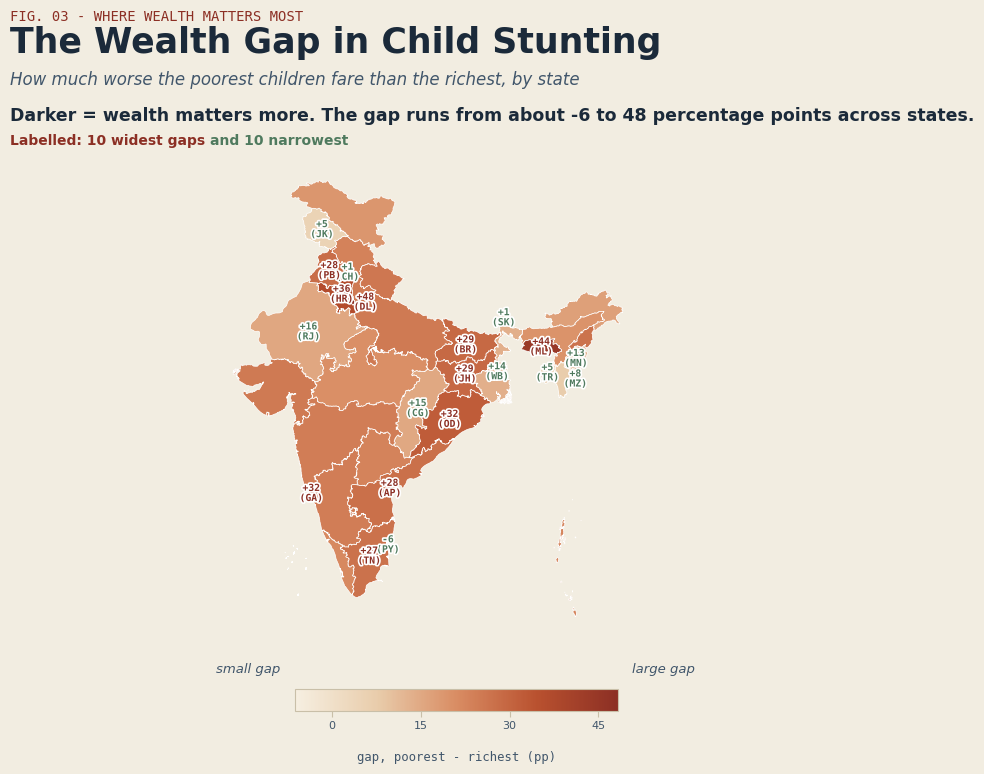

In [13]:
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.ticker import MaxNLocator
from matplotlib import patheffects as pe
import matplotlib as mpl
import numpy as np

gdf = map_data   # must contain gap_pp. Change if your frame is named differently.

# ---- Lahchen Maps palette ----
PAPER="#f2ede1"; INK="#1b2a3a"; INKSOFT="#41566b"; RULE="#c9bfa8"
OXBLOOD="#8c2f24"; GREEN="#4f7a5e"
ramp = LinearSegmentedColormap.from_list("lahchen",
        ["#f6efe1","#e9cdac","#d98c63","#b9512f","#8c2f24"])
HALO = [pe.withStroke(linewidth=2.4, foreground="white")]

STATE_ABBR = {  # states + UTs
 "andhra pradesh":"AP","arunachal pradesh":"AR","assam":"AS","bihar":"BR","chhattisgarh":"CG",
 "goa":"GA","gujarat":"GJ","haryana":"HR","himachal pradesh":"HP","jharkhand":"JH",
 "karnataka":"KA","kerala":"KL","madhya pradesh":"MP","maharashtra":"MH","manipur":"MN",
 "meghalaya":"ML","mizoram":"MZ","nagaland":"NL","odisha":"OD","orissa":"OD","punjab":"PB",
 "rajasthan":"RJ","sikkim":"SK","tamil nadu":"TN","telangana":"TG","tripura":"TR",
 "uttar pradesh":"UP","uttarakhand":"UK","uttaranchal":"UK","west bengal":"WB","delhi":"DL",
 "nct of delhi":"DL","jammu and kashmir":"JK","jammu & kashmir":"JK","puducherry":"PY",
 "chandigarh":"CH","andaman and nicobar":"AN","ladakh":"LA","lakshadweep":"LD"}
def _abbr(n): return STATE_ABBR.get(str(n).strip().lower(), str(n)[:2].upper())

col = "gap_pp"
d = gdf.dropna(subset=[col]).copy()
vmin, vmax = d[col].min(), d[col].max()
hi = d.nlargest(1, col).iloc[0]; lo = d.nsmallest(1, col).iloc[0]

# ---- SAME figure size + map axes as Figure 1 ----
fig = plt.figure(figsize=(9.5, 12)); fig.patch.set_facecolor(PAPER)
ax = fig.add_axes([0.04, 0.46, 0.92, 0.40]); ax.set_facecolor(PAPER); ax.axis("off")

gdf.plot(column=col, cmap=ramp, vmin=vmin, vmax=vmax, linewidth=0.5,
         edgecolor="white", ax=ax,
         missing_kwds={"color":"#dcd4c2","edgecolor":"white","linewidth":0.5})

# label only top 10 + bottom 10 (value + shorthand), coloured by group
dd = d.sort_values(col, ascending=False)
top10 = set(dd.head(10)["name"])   # widest gaps
bot10 = set(dd.tail(10)["name"])   # narrowest gaps

# nudge a few cramped small states to the right (no leader line)
NUDGE = {"delhi": (1, 0), "puducherry": (1, 0), "mizoram": (1, 0)}

keep = top10 | bot10
for _, r in gdf.iterrows():
    if r["name"] not in keep or r.geometry is None:
        continue
    c = r.geometry.centroid
    label_color = OXBLOOD if r["name"] in top10 else GREEN
    dx, dy = NUDGE.get(str(r["name"]).strip().lower(), (0, 0))
    ax.annotate(f"{r[col]:+.0f}\n({_abbr(r['name'])})", (c.x + dx, c.y + dy),
                ha="center", va="center", fontsize=7, color=label_color,
                family="monospace", linespacing=1.0, fontweight="bold",
                path_effects=HALO)

# titles
fig.text(0.06, 0.975, "FIG. 03 - WHERE WEALTH MATTERS MOST", family="monospace", fontsize=10, color=OXBLOOD)
fig.text(0.06, 0.948, "The Wealth Gap in Child Stunting", fontsize=25, fontweight="bold", color=INK)
fig.text(0.06, 0.922, "How much worse the poorest children fare than the richest, by state",
         fontsize=12, color=INKSOFT, style="italic")
fig.text(0.06, 0.892, f"Darker = wealth matters more. The gap runs from about "
         f"{lo[col]:.0f} to {hi[col]:.0f} percentage points across states.",
         fontsize=12.5, color=INK, fontweight="bold")

# legend for the label colours
fig.text(0.06, 0.872, "Labelled: 10 widest gaps", fontsize=10,
         color=OXBLOOD, fontweight="bold")
fig.text(0.27, 0.872, "and 10 narrowest", fontsize=10,
         color=GREEN, fontweight="bold")

# ---- SAME colourbar axes as Figure 1 ----
cax = fig.add_axes([0.36, 0.40, 0.34, 0.018])
cb = mpl.colorbar.ColorbarBase(cax, cmap=ramp, norm=Normalize(vmin, vmax),
                               orientation="horizontal")
cb.outline.set_edgecolor(RULE)
ticks = MaxNLocator(nbins=5, prune="both").tick_values(vmin, vmax)
cb.set_ticks([t for t in ticks if vmin<=t<=vmax])
cb.ax.tick_params(labelsize=8, color=RULE, labelcolor=INKSOFT, length=4, pad=3)
fig.text(0.345, 0.432, "small gap", fontsize=9.5, color=INKSOFT, ha="right", style="italic")
fig.text(0.715, 0.432, "large gap",  fontsize=9.5, color=INKSOFT, ha="left",  style="italic")
fig.text(0.53, 0.358, "gap, poorest - richest (pp)", fontsize=8.8, color=INKSOFT, ha="center", family="monospace")

plt.savefig("fig2_gap_map.png", dpi=400, bbox_inches="tight", facecolor=PAPER)
plt.show()

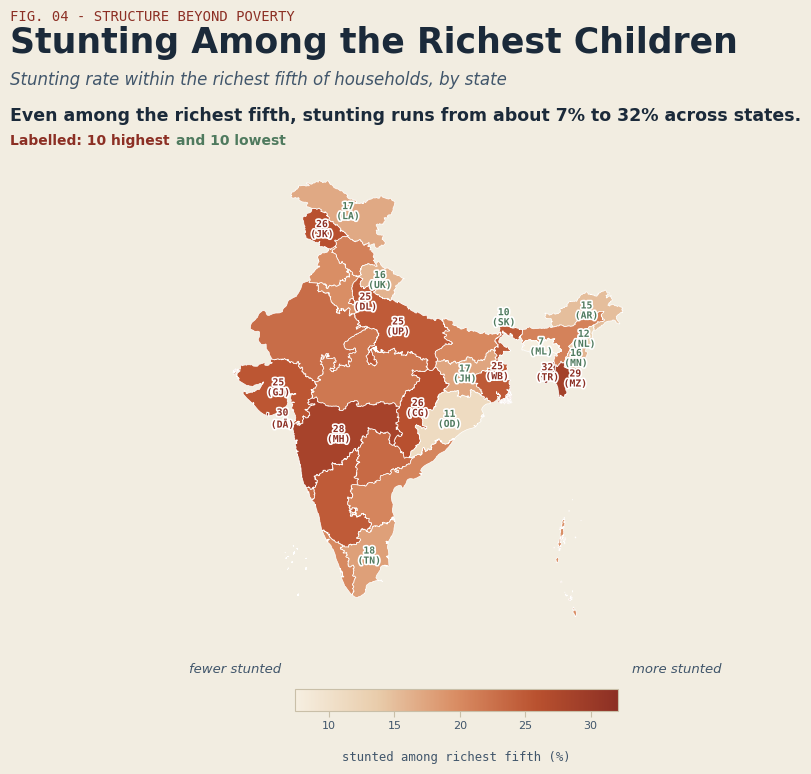

In [14]:
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.ticker import MaxNLocator
from matplotlib import patheffects as pe
import matplotlib as mpl
import numpy as np

gdf = map_data

# ---- Lahchen Maps palette ----
PAPER="#f2ede1"; INK="#1b2a3a"; INKSOFT="#41566b"; RULE="#c9bfa8"
OXBLOOD="#8c2f24"; GREEN="#4f7a5e"
ramp = LinearSegmentedColormap.from_list("lahchen",
        ["#f6efe1","#e9cdac","#d98c63","#b9512f","#8c2f24"])
HALO = [pe.withStroke(linewidth=2.4, foreground="white")]

STATE_ABBR = {  # states + UTs
 "andhra pradesh":"AP","arunachal pradesh":"AR","assam":"AS","bihar":"BR","chhattisgarh":"CG",
 "goa":"GA","gujarat":"GJ","haryana":"HR","himachal pradesh":"HP","jharkhand":"JH",
 "karnataka":"KA","kerala":"KL","madhya pradesh":"MP","maharashtra":"MH","manipur":"MN",
 "meghalaya":"ML","mizoram":"MZ","nagaland":"NL","odisha":"OD","orissa":"OD","punjab":"PB",
 "rajasthan":"RJ","sikkim":"SK","tamil nadu":"TN","telangana":"TG","tripura":"TR",
 "uttar pradesh":"UP","uttarakhand":"UK","uttaranchal":"UK","west bengal":"WB","delhi":"DL",
 "nct of delhi":"DL","jammu and kashmir":"JK","jammu & kashmir":"JK","puducherry":"PY",
 "chandigarh":"CH","andaman and nicobar":"AN","ladakh":"LA","lakshadweep":"LD"}
def _abbr(n): return STATE_ABBR.get(str(n).strip().lower(), str(n)[:2].upper())

col = "rich_pct"
d = gdf.dropna(subset=[col]).copy()
vmin, vmax = d[col].min(), d[col].max()
hi = d.nlargest(1, col).iloc[0]; lo = d.nsmallest(1, col).iloc[0]

# ---- SAME figure size + map axes as Figure 1 ----
fig = plt.figure(figsize=(9.5, 12)); fig.patch.set_facecolor(PAPER)
ax = fig.add_axes([0.04, 0.46, 0.92, 0.40]); ax.set_facecolor(PAPER); ax.axis("off")

gdf.plot(column=col, cmap=ramp, vmin=vmin, vmax=vmax, linewidth=0.5,
         edgecolor="white", ax=ax,
         missing_kwds={"color":"#dcd4c2","edgecolor":"white","linewidth":0.5})

# label only top 10 + bottom 10 (value + shorthand), coloured by group
dd = d.sort_values(col, ascending=False)
top10 = set(dd.head(10)["name"])   # highest stunting among the rich
bot10 = set(dd.tail(10)["name"])   # lowest

# nudge a few cramped small states to the right (no leader line)
NUDGE = {"delhi": (1, 0), "puducherry": (1, 0), "mizoram": (1, 0)}

keep = top10 | bot10
for _, r in gdf.iterrows():
    if r["name"] not in keep or r.geometry is None:
        continue
    c = r.geometry.centroid
    label_color = OXBLOOD if r["name"] in top10 else GREEN
    dx, dy = NUDGE.get(str(r["name"]).strip().lower(), (0, 0))
    ax.annotate(f"{r[col]:.0f}\n({_abbr(r['name'])})", (c.x + dx, c.y + dy),
                ha="center", va="center", fontsize=7, color=label_color,
                family="monospace", linespacing=1.0, fontweight="bold",
                path_effects=HALO)

# titles
fig.text(0.06, 0.975, "FIG. 04 - STRUCTURE BEYOND POVERTY", family="monospace", fontsize=10, color=OXBLOOD)
fig.text(0.06, 0.948, "Stunting Among the Richest Children", fontsize=25, fontweight="bold", color=INK)
fig.text(0.06, 0.922, "Stunting rate within the richest fifth of households, by state",
         fontsize=12, color=INKSOFT, style="italic")
fig.text(0.06, 0.892, f"Even among the richest fifth, stunting runs from about "
         f"{lo[col]:.0f}% to {hi[col]:.0f}% across states.",
         fontsize=12.5, color=INK, fontweight="bold")

# legend for the label colours
fig.text(0.06, 0.872, "Labelled: 10 highest", fontsize=10,
         color=OXBLOOD, fontweight="bold")
fig.text(0.235, 0.872, "and 10 lowest", fontsize=10,
         color=GREEN, fontweight="bold")

# ---- SAME colourbar axes as Figure 1 ----
cax = fig.add_axes([0.36, 0.40, 0.34, 0.018])
cb = mpl.colorbar.ColorbarBase(cax, cmap=ramp, norm=Normalize(vmin, vmax),
                               orientation="horizontal")
cb.outline.set_edgecolor(RULE)
ticks = MaxNLocator(nbins=5, prune="both").tick_values(vmin, vmax)
cb.set_ticks([t for t in ticks if vmin<=t<=vmax])
cb.ax.tick_params(labelsize=8, color=RULE, labelcolor=INKSOFT, length=4, pad=3)
fig.text(0.345, 0.432, "fewer stunted", fontsize=9.5, color=INKSOFT, ha="right", style="italic")
fig.text(0.715, 0.432, "more stunted",  fontsize=9.5, color=INKSOFT, ha="left",  style="italic")
fig.text(0.53, 0.358, "stunted among richest fifth (%)", fontsize=8.8, color=INKSOFT, ha="center", family="monospace")

plt.savefig("fig4_rich_map.png", dpi=400, bbox_inches="tight", facecolor=PAPER)
plt.show()

In [15]:
print([c for c in map_data.columns if "rich" in c.lower() or "rate" in c.lower()])

['poor_rate', 'rich_rate', 'rich_pct']
